In [2]:
%cd d:\Troida

import sys, os
project_root = os.path.abspath(".")
if project_root not in sys.path: sys.path.insert(0, project_root)

d:\Troida


In [3]:
from types import SimpleNamespace

# настройки catboost, задавать перед запуском
SETTINGS = SimpleNamespace(
    csv="./data/21.10.2024 13.00.00 - 21.10.2025 13.00.00/YDEX_2H_20241021_130000_20251021_130000.csv",
    lookback=1000,
    horizon=100,
    step=20,
    cost_bps=5.0,
    periods="",
    bands="",
    cat_overrides="",
)

Карта классов:
0 {'period': 9, 'lower': 20, 'upper': 80}
1 {'period': 9, 'lower': 30, 'upper': 70}
2 {'period': 14, 'lower': 20, 'upper': 80}
3 {'period': 14, 'lower': 30, 'upper': 70}
4 {'period': 21, 'lower': 20, 'upper': 80}
5 {'period': 21, 'lower': 30, 'upper': 70}


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.7898765	test: 1.7918730	best: 1.7918730 (0)	total: 1.69ms	remaining: 6.77s
100:	learn: 1.6007827	test: 1.7414073	best: 1.7411598 (99)	total: 174ms	remaining: 6.71s
200:	learn: 1.4354525	test: 1.7139575	best: 1.7139575 (200)	total: 334ms	remaining: 6.32s
300:	learn: 1.2801538	test: 1.6831408	best: 1.6831408 (300)	total: 511ms	remaining: 6.28s
400:	learn: 1.1520409	test: 1.6751535	best: 1.6744917 (390)	total: 688ms	remaining: 6.17s
500:	learn: 1.0468945	test: 1.6726391	best: 1.6713155 (485)	total: 873ms	remaining: 6.1s
600:	learn: 0.9588609	test: 1.6725430	best: 1.6713155 (485)	total: 1.04s	remaining: 5.89s
700:	learn: 0.8804311	test: 1.6710942	best: 1.6698236 (656)	total: 1.2s	remaining: 5.65s
800:	learn: 0.8154852	test: 1.6762573	best: 1.6698236 (656)	total: 1.36s	remaining: 5.42s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1.669823646
bestIteration = 656

Shrink model to first 657 iterations.
Holdout accuracy: 0.26666666666666666
Рекомендованные пара

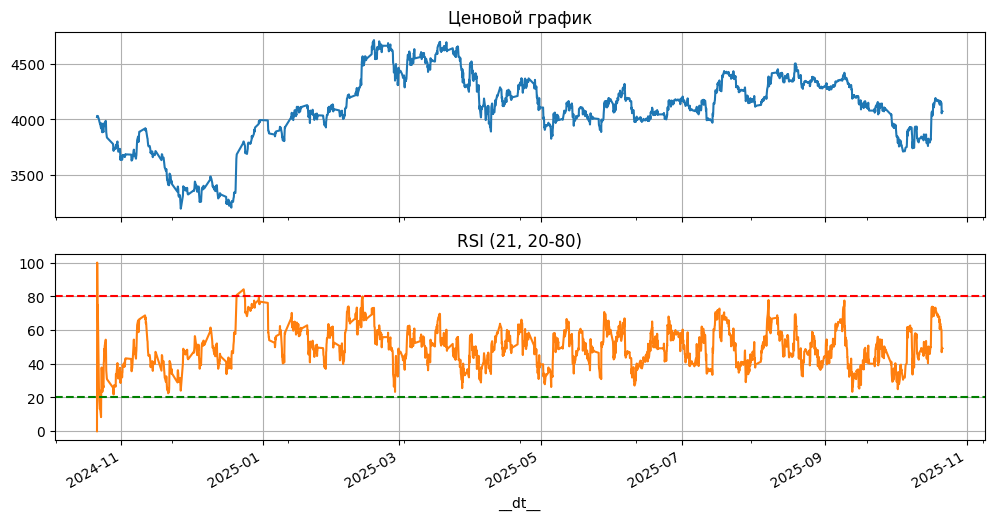

Лучшие параметры: {'period': 21, 'lower': 20, 'upper': 80}


In [ ]:
from types import SimpleNamespace
import matplotlib.pyplot as plt
from rsi import run_pipeline, compute_rsi

# Запуск пайплайна (аргументы из SETTINGS)
args = SimpleNamespace(
    csv=SETTINGS.csv,
    lookback=SETTINGS.lookback,
    horizon=SETTINGS.horizon,
    step=SETTINGS.step,
    cost_bps=SETTINGS.cost_bps,
    periods=SETTINGS.periods,
    bands=SETTINGS.bands,
    cat_overrides=SETTINGS.cat_overrides,
    plot=True,   # включаем интерактивный MetricVisualizer от CatBoost
)
result = run_pipeline(args, verbose=True)

df = result["df"]
best_params = result["best_params"]
rsi_series = compute_rsi(df["close"], best_params["period"]).fillna(50)

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
df["close"].plot(ax=ax[0], title="Ценовой график")
ax[0].grid(True)

rsi_series.plot(ax=ax[1], color="tab:orange", title=f"RSI ({best_params['period']}, {best_params['lower']}-{best_params['upper']})",)
ax[1].axhline(best_params["lower"], color="green", linestyle="--")
ax[1].axhline(best_params["upper"], color="red", linestyle="--")
ax[1].grid(True)

plt.show()